Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler



In [3]:
#Загружаем данные в Датафрейм

df = pd.read_csv('AB_NYC_2019.csv')

In [4]:
# смотрим 5 первых строк
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


id - id объявления <u>(не влияет на цену)</u>  
name - название арендного помещений  <u>(не влияет на цену)</u>  
host_id	- id хозяина  <u>(не влияет на цену)</u>  
host_name - Имя хозяина <u>(не влияет на цену)</u>
neighbourhood_group - группа районов(округ)  
neighbourhood - район  
latitude - широта  
longitude - долгота  
room_type - тип комнаты/жилья  
**price - цена за ночь(целевая переменная)**  
minimum_nights - минимальное кол-во ночей для бронирования  
number_of_reviews - кол-во отзывов  
last_review - дата последнего отзыва  <u>(не влияет на цену)</u>
reviews_per_month - среднее кол-во отзывов за месяц  
calculated_host_listings_count - кол-во объявлений у этого хозяина  
availability_365 - сколько дней в году жилье свободно для бронирования (не бронировалось)  


In [5]:
# Размер датафрейма
df.shape

(48895, 16)

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [7]:
#Удаляем id, name, host_id	host_name last_review - не влияют на цену и имеют пропуски
df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.1 MB


In [8]:
# пустые значения есть в reviews_per_month. Проверим весь датафрейм. 
df.isna().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [9]:
# reviews_per_month - среднее кол-во отзывов в месяц. Если пустое значение, то отзывов скорее всего нет.
# Заменяем на нули. Ставить другие численные значения нельзя, так как это может повлиять на цену. 
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)


In [10]:
# Проверяем
df.info()
#пропусков нет

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.1 MB


In [11]:
# Смотрим на типы данных

df.dtypes
# neighbourhood_group, neighbourhood, room_type - категориальные признаки, остальные числовые. 

neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [12]:
# Проверяем статистику числовых признаков
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [119]:
# Выводы: 
# 1. Все признаки в разных единицах измерения, потребуется масштабирование
# 2. price - 75% - 175, а max - 100000, значит есть выбросы
# 3. price - есть нули, но квартиры бесплатно не сдаются. Ставить среднее некорректно, лучше удалить. 
# 4. minimum_nights - среднее 7, максимум - 1250. Выброс. Необходимо обработать. 
# 5. Аvailability_365 - 25% квартир никогда не сдаются. Удалять их нельзя, потеряем 25% данных, но нужно обработать.  


In [14]:
# Удаляем нулевые цены
df_base = df[df['price'] > 0].copy()
df_base.info()

<class 'pandas.DataFrame'>
Index: 48884 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48884 non-null  str    
 1   neighbourhood                   48884 non-null  str    
 2   latitude                        48884 non-null  float64
 3   longitude                       48884 non-null  float64
 4   room_type                       48884 non-null  str    
 5   price                           48884 non-null  int64  
 6   minimum_nights                  48884 non-null  int64  
 7   number_of_reviews               48884 non-null  int64  
 8   reviews_per_month               48884 non-null  float64
 9   calculated_host_listings_count  48884 non-null  int64  
 10  availability_365                48884 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.5 MB


In [ ]:
# Визуальный анализ

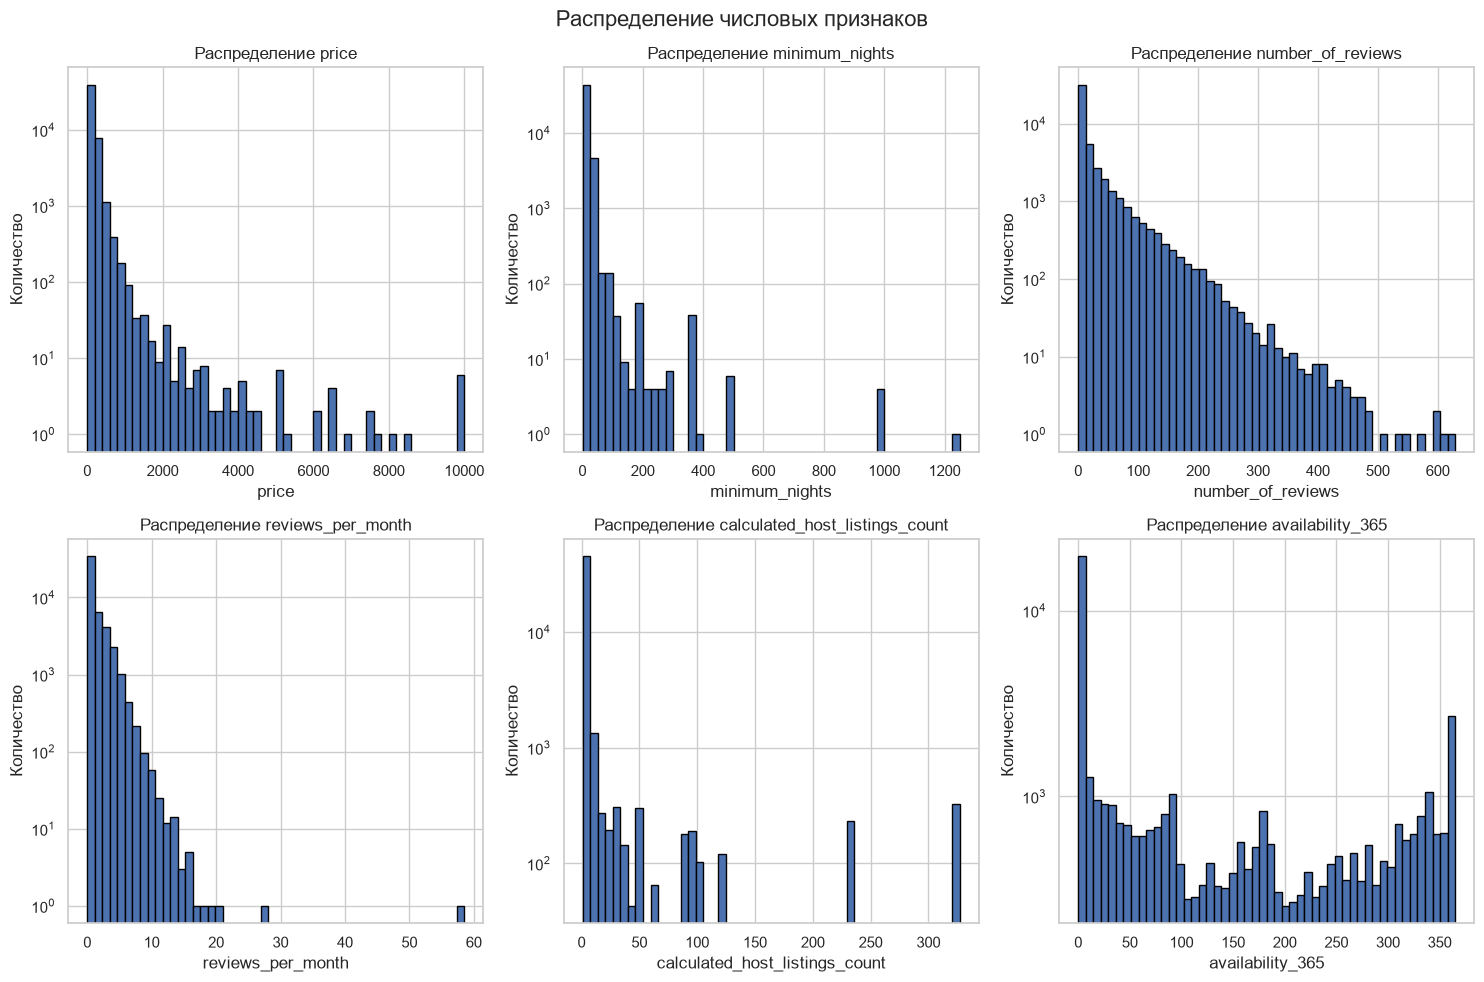

In [120]:
#Визуализируем распределение признаков

# Настройка стилей
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

#Выбираем числовые колоники, чтобы категориальные не влияли на графики

numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

# Гистограммы распределения числовых признаков

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=1)
    axes[i].set_title(f'Распределение {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')
    axes[i].set_yscale('log')

plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

# Выводы: Price - выброс 10000, минимальное кол-во ночей - 1000 и 1200 -х аномалии, доступность - 0 - большой выброс



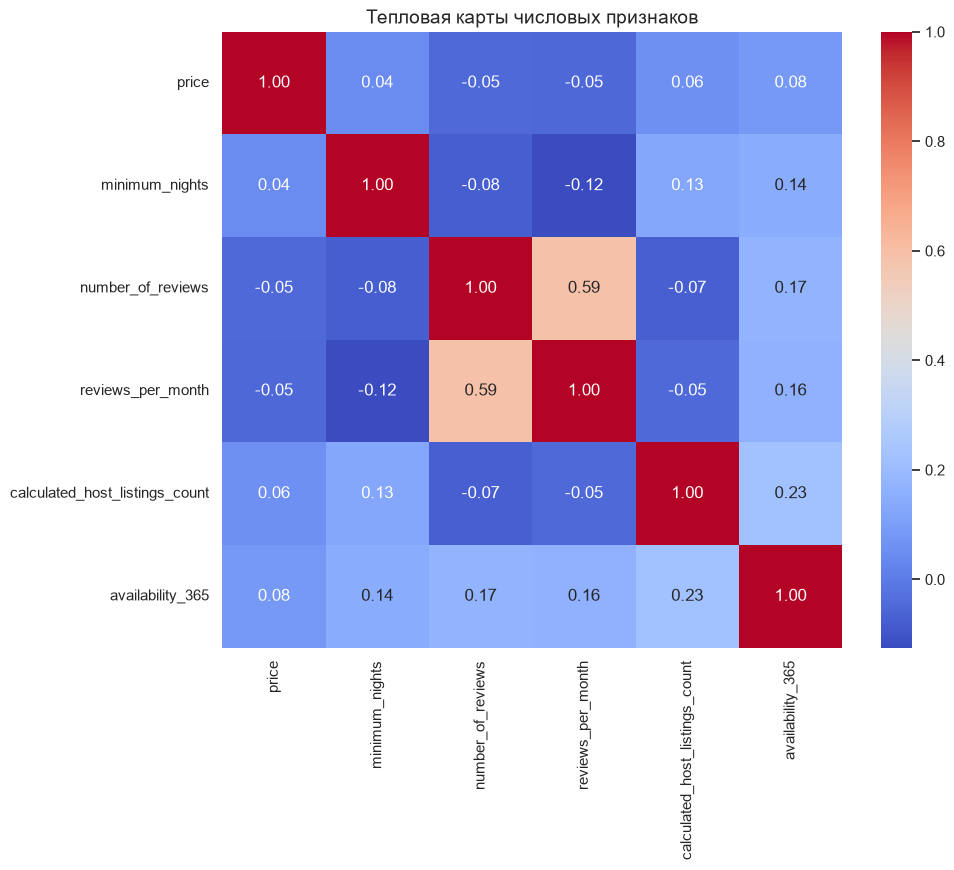

In [121]:
#Матрица корреляций (тепловая карта)

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), 
            annot=True,        # Показываем цифры
            fmt='.2f',         # Два знака после запятой
            cmap='coolwarm'   # Цветовая схема
            )
plt.title('Тепловая карты числовых признаков', fontsize=14)
plt.show()

# Выводы: Средняя корреляция между number_of_reviews и reviews_per_month. 
# Коррелируют, но не зависят друг от друга. 
# Оставляем оба. 
# Остальные признаки слабо коррелируют. 
# Цена скорее всего зависит от категориальных признаков. 



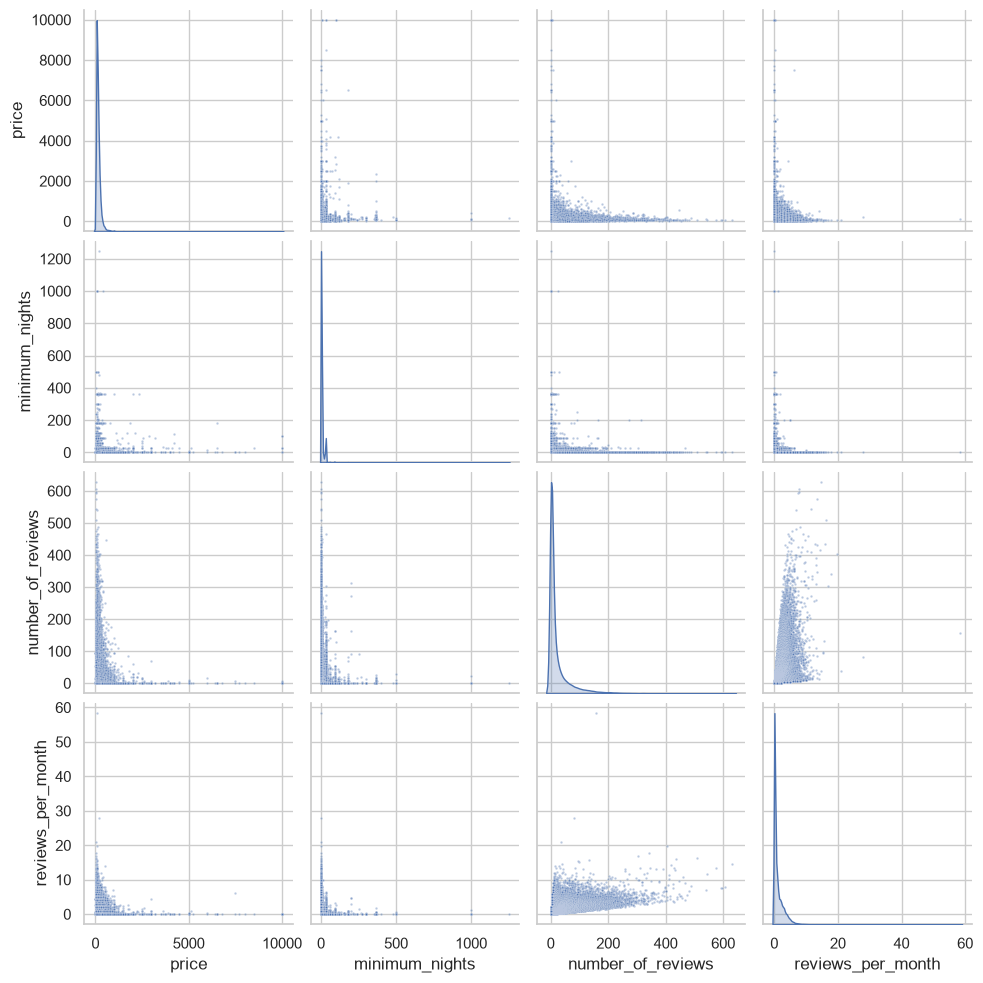

In [122]:
#Строим Pair Plots

# Для парных графиков возьмем самые важные признаки
pair_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']

sns.pairplot(df[pair_cols], 
             diag_kind='kde',
             markers='.',
             plot_kws={'alpha': 0.4, 's': 12},
             diag_kws={'fill': True},
             );

# Выводы: Связь между ценой и числовыми признаками очень слабая. 
# Выбросы есть на всех признаках, требуют обработки.  

In [123]:
# Посмотрим категориальные признаки
df[['neighbourhood_group', 'neighbourhood', 'room_type']].describe()

,neighbourhood_group,neighbourhood,room_type
count,48895,48895,48895
unique,5,221,3
top,Manhattan,Williamsburg,Entire home/apt
freq,21661,3920,25409


In [124]:
# Посмотрим кол-во уникальных значение в каждом признаке
for col in ['neighbourhood_group', 'neighbourhood', 'room_type']:
    print('\n')
    print(df[col].value_counts().head(5))

# Вывод: neighbourhood_group  и room_type будем кодировать через OHE, а neighbourhood через 




neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Name: count, dtype: int64


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


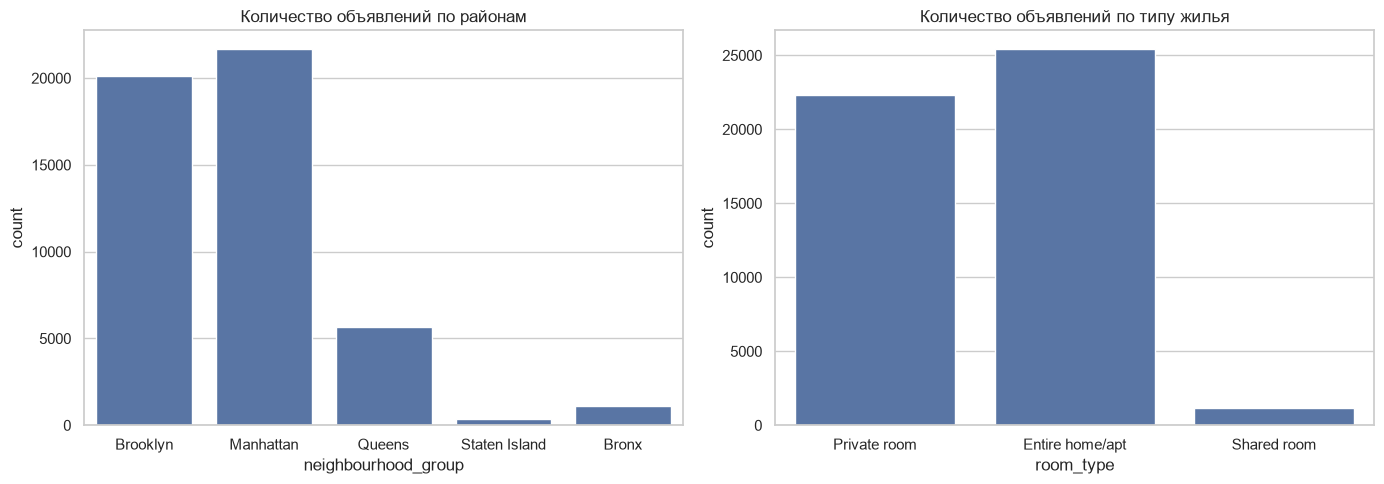

In [125]:
# Посмотрим кол-во объявлений по районам и типу жилья

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(data=df, x='neighbourhood_group', ax=axes[0])
axes[0].set_title('Количество объявлений по районам')

sns.countplot(data=df, x='room_type', ax=axes[1])
axes[1].set_title('Количество объявлений по типу жилья')

plt.tight_layout()
plt.show()

#Выводы: Основное жилье под сдачу в Манхеттене и Бруклине
# Цена зависит от района и от типа жилья.



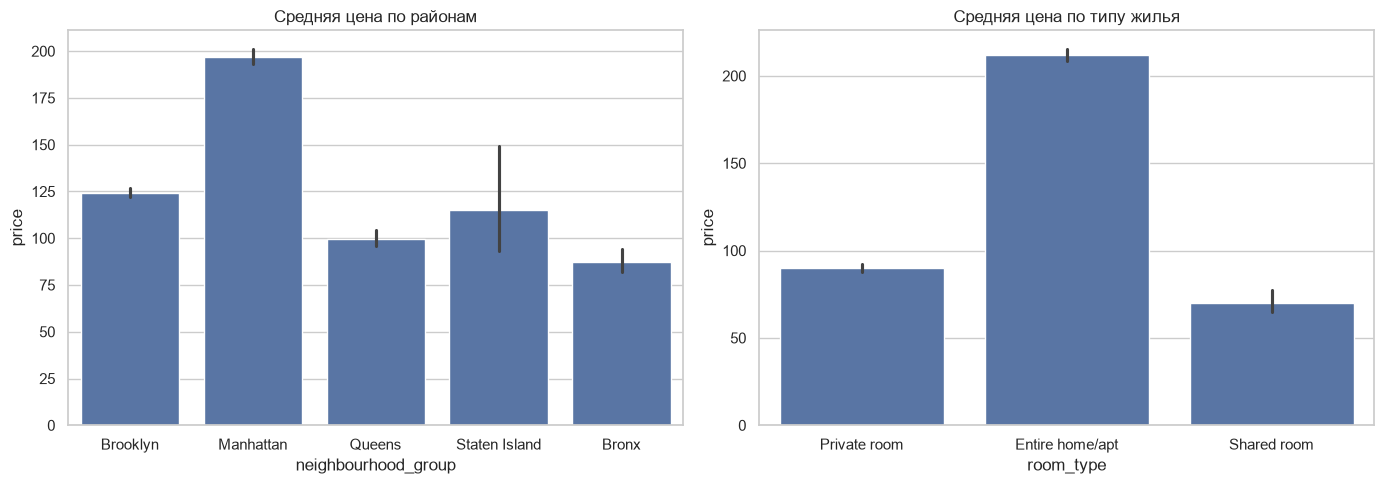

In [126]:
# Посмотрим среднюю цену по районам и типу жилья

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.barplot(data=df, x='neighbourhood_group', y='price', ax=axes[0], 
            estimator='mean')
axes[0].set_title('Средняя цена по районам')

sns.barplot(data=df, x='room_type', y='price', ax=axes[1], estimator='mean')
axes[1].set_title('Средняя цена по типу жилья')

plt.tight_layout()
plt.show()

In [16]:
# One hot encoding для категориальных признаков
df_encoded_base = pd.get_dummies(df,
                                 columns=['neighbourhood_group', 'neighbourhood', 'room_type'], 
                                 drop_first=True)
df_encoded_base


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,...,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,0.21,6,365,True,False,...,False,False,False,False,False,False,False,False,True,False
1,40.75362,-73.98377,225,1,45,0.38,2,355,False,True,...,False,False,False,False,False,False,False,False,False,False
2,40.80902,-73.94190,150,3,0,0.00,1,365,False,True,...,False,False,False,False,False,False,False,False,True,False
3,40.68514,-73.95976,89,1,270,4.64,1,194,True,False,...,False,False,False,False,False,False,False,False,False,False
4,40.79851,-73.94399,80,10,9,0.10,1,0,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,40.67853,-73.94995,70,2,0,0.00,2,9,True,False,...,False,False,False,False,False,False,False,False,True,False
48891,40.70184,-73.93317,40,4,0,0.00,2,36,True,False,...,False,False,False,False,False,False,False,False,True,False
48892,40.81475,-73.94867,115,10,0,0.00,1,27,False,True,...,False,False,False,False,False,False,False,False,False,False
48893,40.75751,-73.99112,55,1,0,0.00,6,2,False,True,...,False,False,False,False,False,False,False,False,False,True


# Моделирование

In [19]:
# Разбиваем на обучающие данные и результат

X_base = df_encoded_base.drop(columns=['price'])
y_base = df_encoded_base['price']

# Делим данные на обучающие и тестовые (30%)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.3, random_state=42)


# Масштабируем числовые признаки 

# Список числовых признаков (все, кроме бинарных от OHE)
numeric_cols_base = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
                     'reviews_per_month', 'calculated_host_listings_count',
                     'availability_365']

scaler = StandardScaler()
X_train_base[numeric_cols_base] = scaler.fit_transform(X_train_base[numeric_cols_base])
X_test_base[numeric_cols_base] = scaler.transform(X_test_base[numeric_cols_base])


base_models = {
    'Linear Regression': LinearRegression(),
    'RidgeCV': RidgeCV(cv=5),
    'LassoCV': LassoCV(cv=5, random_state=42),
    'ElasticNetCV': ElasticNetCV(cv=5, random_state=42)
}

base_results = []
for name, model in base_models.items():
    model.fit(X_train_base, y_train_base)
    y_pred_base = model.predict(X_test_base)
    
    base_results.append({
        'model': name,
        'R2': r2_score(y_test_base, y_pred_base),
        'RMSE': np.sqrt(mean_squared_error(y_test_base, y_pred_base)),
        'MAE': mean_absolute_error(y_test_base, y_pred_base)
    })


base_results_df = pd.DataFrame(base_results).set_index('model')
print(base_results_df.round(4))

                       R2      RMSE      MAE
model                                       
Linear Regression  0.1508  185.1894  69.2982
RidgeCV            0.1532  184.9320  68.9516
LassoCV            0.1511  185.1571  68.8317
ElasticNetCV       0.1363  186.7685  69.7953


# Улучшенная модель

In [20]:
# Подготовка данных - копирование исходного датасета

df_mod = df.copy()

In [21]:
# Удаляем нулевые цены и верхние выбросы 1%
df_mod = df_mod[df_mod['price'] > 0].copy()

price_upper = df_mod['price'].quantile(0.99)
df_mod = df_mod[df_mod['price'] <= price_upper].copy()

In [22]:
# Создаем новый признак расстояние до центра Манхеттена

# координаты из интернет
manhattan_lat = 40.7833
manhattan_lon = -73.9667

# считаем расстояние по декарту

df_mod['distance_to_manhattan'] = np.sqrt(
    (df_mod['latitude'] - manhattan_lat) ** 2 +
    (df_mod['longitude'] - manhattan_lon) ** 2
)

In [ ]:
# Разбиваем на признаки и целевую переменную
X_mod = df_mod.drop(columns=['price'])
y_mod = df_mod['price']

In [24]:
# Делим данные на обучающие данные и тестовые (30%)
X_train_mod, X_test_mod, y_train_mod, y_test_mod = train_test_split(
    X_mod, y_mod, test_size=0.3, random_state=42
)

In [25]:
# **Обработка выбросов после разбивки, чтобы предотвратить утечку данных**
cols_to_clip = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365']

clip_values = {}
for col in cols_to_clip:
    clip_values[col] = X_train_mod[col].quantile(0.99)

for col in cols_to_clip:
    X_train_mod[col] = X_train_mod[col].clip(upper=clip_values[col])
    X_test_mod[col] = X_test_mod[col].clip(upper=clip_values[col])

In [26]:
# Логарифмируем целевую переменную
y_train_mod_log = np.log1p(y_train_mod)
y_test_mod_log = np.log1p(y_test_mod)

In [28]:
# Target encoding для neighbourhood только на тренировочных данных

train_temp = X_train_mod.copy()
train_temp['log_price'] = y_train_mod_log

category_mean = train_temp.groupby('neighbourhood')['log_price'].mean()
global_mean = y_train_mod_log.mean()

X_train_mod['neighbourhood_encoded'] = X_train_mod['neighbourhood'].map(category_mean)
X_test_mod['neighbourhood_encoded'] = X_test_mod['neighbourhood'].map(category_mean)

X_train_mod['neighbourhood_encoded'] = X_train_mod['neighbourhood_encoded'].fillna(global_mean)
X_test_mod['neighbourhood_encoded'] = X_test_mod['neighbourhood_encoded'].fillna(global_mean)

In [29]:
# OHE для neighbourhood_group и room_type
X_train_mod = pd.get_dummies(X_train_mod, columns=['neighbourhood_group', 'room_type'], drop_first=True)
X_test_mod = pd.get_dummies(X_test_mod, columns=['neighbourhood_group', 'room_type'], drop_first=True)


In [30]:
# Выравниваем train и test по столбцам
X_train_mod, X_test_mod = X_train_mod.align(X_test_mod, join='left', axis=1, fill_value=0)

In [31]:
# Удаляем исходный neighbourhood
X_train_mod.drop('neighbourhood', axis=1, inplace=True)
X_test_mod.drop('neighbourhood', axis=1, inplace=True)

In [32]:
# Логарифмируем числовые признаки
cols_to_log = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
               'calculated_host_listings_count']

for col in cols_to_log:
    X_train_mod[f'log_{col}'] = np.log1p(X_train_mod[col])
    X_test_mod[f'log_{col}'] = np.log1p(X_test_mod[col])

X_train_mod.drop(cols_to_log, axis=1, inplace=True)
X_test_mod.drop(cols_to_log, axis=1, inplace=True)

In [33]:
# Масштабируем числовые признаки 

# Список числовых признаков (все, кроме бинарных от OHE и TE)
numeric_cols_mod = ['availability_365', 'neighbourhood_encoded', 'latitude', 'longitude',
                    'distance_to_manhattan', 'log_minimum_nights', 'log_number_of_reviews',
                    'log_reviews_per_month', 'log_calculated_host_listings_count']

scaler = StandardScaler()
X_train_mod[numeric_cols_mod] = scaler.fit_transform(X_train_mod[numeric_cols_mod])
X_test_mod[numeric_cols_mod] = scaler.transform(X_test_mod[numeric_cols_mod])


mod_models = {
    'Linear Regression': LinearRegression(),
    'RidgeCV': RidgeCV(cv=5),
    'LassoCV': LassoCV(cv=5, random_state=42),
    'ElasticNetCV': ElasticNetCV(cv=5, random_state=42)
}

mod_results = []
for name, model in mod_models.items():
    model.fit(X_train_mod, y_train_mod)
    y_pred_mod = model.predict(X_test_mod)
    
    mod_results.append({
        'model': name,
        'R2': r2_score(y_test_mod, y_pred_mod),
        'RMSE': np.sqrt(mean_squared_error(y_test_mod, y_pred_mod)),
        'MAE': mean_absolute_error(y_test_mod, y_pred_mod)
    })


mod_results_df = pd.DataFrame(mod_results).set_index('model')
print(mod_results_df.round(4))

                       R2     RMSE      MAE
model                                      
Linear Regression  0.4138  79.0459  50.2857
RidgeCV            0.4138  79.0459  50.2844
LassoCV            0.4136  79.0535  50.2728
ElasticNetCV       0.3933  80.4112  50.7849


In [34]:
# Сравнение результатов

comparison_df = pd.concat(
    [
        base_results_df.add_prefix('base_'),
        mod_results_df.add_prefix('mod_')
    ],
    axis=1
)

print('\nСравнение результатов')
print(comparison_df.round(4))


Сравнение результатов
                   base_R2  base_RMSE  base_MAE  mod_R2  mod_RMSE  mod_MAE
model                                                                     
Linear Regression   0.1508   185.1894   69.2982  0.4138   79.0459  50.2857
RidgeCV             0.1532   184.9320   68.9516  0.4138   79.0459  50.2844
LassoCV             0.1511   185.1571   68.8317  0.4136   79.0535  50.2728
ElasticNetCV        0.1363   186.7685   69.7953  0.3933   80.4112  50.7849


In [36]:
# Подбор гиперпараметров

# для Ridge
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_mod, y_train_mod_log)

print('\nЛучшие параметры Ridge:')
print(ridge_grid.best_params_)

# для Lasso
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_mod, y_train_mod_log)

print('\nЛучшие параметры Lasso:')
print(lasso_grid.best_params_)

# для ElasticNet
elastic_params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_grid = GridSearchCV(ElasticNet(max_iter=10000), elastic_params, cv=5, scoring='r2')
elastic_grid.fit(X_train_mod, y_train_mod_log)

print('\nЛучшие параметры ElasticNet:')
print(elastic_grid.best_params_)



Лучшие параметры Ridge:
{'alpha': 1.0}

Лучшие параметры Lasso:
{'alpha': 0.0001}

Лучшие параметры ElasticNet:
{'alpha': 0.0001, 'l1_ratio': 0.1}


In [37]:
# Результаты после подбора гиперпараметров

tuned_models = {
    'Ridge_tuned': ridge_grid.best_estimator_,
    'Lasso_tuned': lasso_grid.best_estimator_,
    'ElasticNet_tuned': elastic_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    model.fit(X_train_mod, y_train_mod_log)
    y_pred_log = model.predict(X_test_mod)

    y_pred = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test_mod_log)

    tuned_results.append({
        'model': name,
        'R2': r2_score(y_test_actual, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_actual, y_pred)),
        'MAE': mean_absolute_error(y_test_actual, y_pred)
    })

tuned_results_df = pd.DataFrame(tuned_results).set_index('model')
print('\nРезультаты после подбора гиперпараметров')
print(tuned_results_df.round(4))



Результаты после подбора гиперпараметров
                      R2     RMSE      MAE
model                                     
Ridge_tuned       0.4052  79.6201  45.9374
Lasso_tuned       0.4050  79.6329  45.9418
ElasticNet_tuned  0.4051  79.6257  45.9373


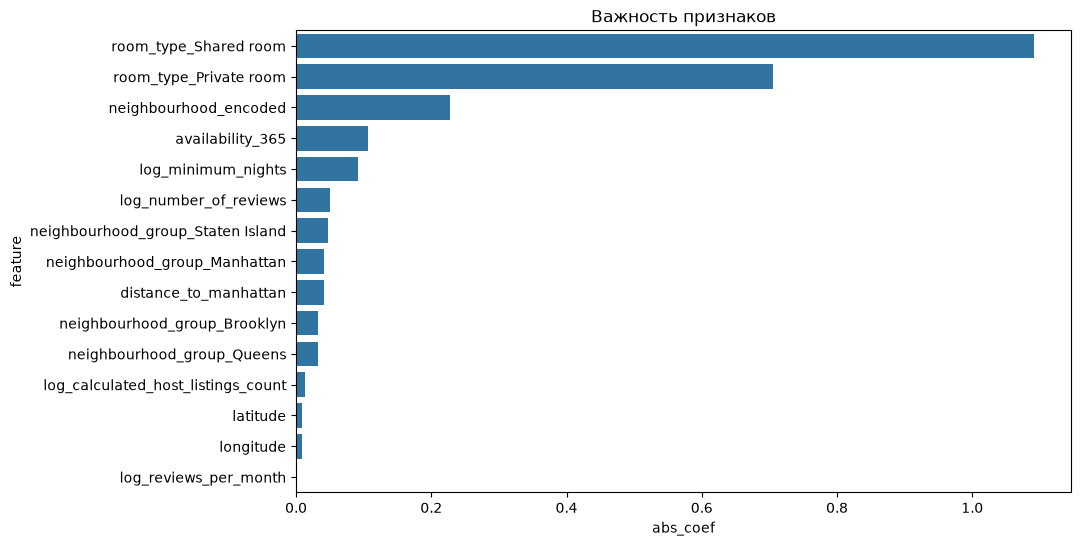

In [39]:
# Важность параметров

# Лучшая модель по R2 - Ridge

best_model = ridge_grid.best_estimator_
best_model.fit(X_train_mod, y_train_mod_log)

coef_df = pd.DataFrame({
    'feature': X_train_mod.columns,
    'coef': best_model.coef_
})

coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='abs_coef', y='feature')
plt.title('Важность признаков')
plt.show()

In [ ]:
# Выводы: 
# Проведены обработка данных и добавление новых признаков. 
# Сравнение результатов на разных моделях. 
# Подбор гиперпараметров.
# Лучшей моделью по R2 оказалась модель Ridge.
# Цена зависит от типа комнаты, района и доступности к бронированию в течение года. 

